# Autómatas de Impacto sobre Quivers (AIQ)
## Aplicación a Grafos de Citación

Este notebook implementa y demuestra la teoría de **Autómatas de Impacto sobre Quivers** definida en:

> Zainea Maya & Moreno Cañadas, *"Autómatas de Impacto sobre Quivers: Un Marco Algebraico para Modelar Dinámicas de Sistemas Complejos"*

### Contenido

1. Quivers: construcción y propiedades básicas
2. Grado y vector de impacto
3. Álgebra de caminos kQ
4. Ideales y cociente kQ/I
5. Sistema Fundamental de Vecindades (SFV)
6. Tasas de impacto
7. Simulación SIS en quiver de 4 nodos (Ejemplo 3.1)
8. Quiver de citación de 5 artículos (Ejemplo 4.1)
9. Tasa enriquecida vs. simple vs. con ideal
10. AIQ con signo: red de regulación génica
11. Dataset Cora
12. Simulación AIQ en Cora
13. Estadísticas Monte Carlo
14. Morfismos de quivers y AIQs

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Paquete AIQ
from aiq import (
    Quiver, Path, PathAlgebra, PathAlgebraElement, Ideal, QuotientAlgebra,
    impact_degree, impact_vector, impact_vector_matrix,
    FundamentalNeighborhoodSystem,
    impact_rate_simple, impact_rate_enriched, impact_rate_signed,
    AIQ,
)
from aiq import morphisms, visualization, datasets

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
print("Paquete AIQ cargado correctamente.")

Paquete AIQ cargado correctamente.


---
## 1. Quivers: Construcción y Propiedades Básicas

Un **quiver** $Q = (Q_0, Q_1, s, t)$ es un grafo dirigido donde:
- $Q_0$ = conjunto de vértices (células)
- $Q_1$ = conjunto de flechas
- $s, t: Q_1 \to Q_0$ = funciones fuente y objetivo

Usamos el quiver de 4 nodos del **Ejemplo 2.3** del artículo.

In [3]:
# Construir el quiver de 4 nodos (Ejemplo 2.3)
Q = datasets.example_4node_quiver()
print(Q.summary())
print()
print("Matriz de adyacencia A:")
print(Q.adjacency_matrix())

Quiver(|Q_0|=4, |Q_1|=5, vertices=[1, 2, 3, 4])
  Flechas: α₁:1→2, α₂:1→2, γ:1→3, β:2→4, δ:3→4
  Fuentes (trampas topológicas): [1]
  Sumideros: [4]
  DAG: True
  Diámetro: 2

Matriz de adyacencia A:
[[0. 2. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 0.]]


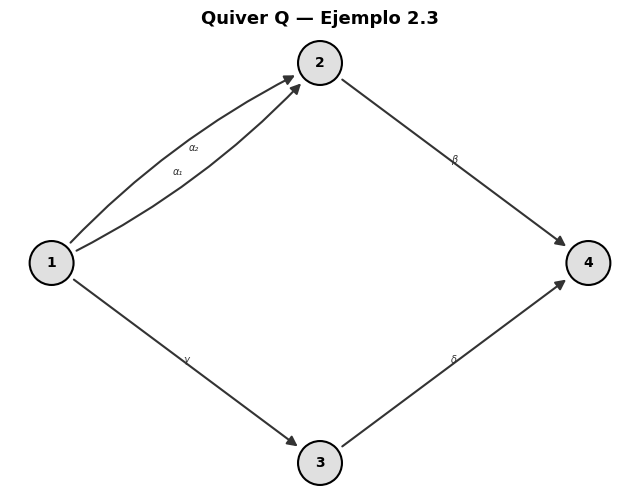

In [4]:
# Visualizar el quiver
pos = {1: (0, 1), 2: (1, 1.5), 3: (1, 0.5), 4: (2, 1)}
fig, ax = visualization.draw_quiver(
    Q, pos=pos, show_arrow_labels=True,
    title="Quiver Q — Ejemplo 2.3",
    node_size=1000,
)
plt.show()

**Observaciones:**
- Hay **dos flechas** de 1 a 2 ($\alpha_1$ y $\alpha_2$): esto es un quiver, no un grafo simple.
- $A_{1,2} = 2$ refleja las flechas múltiples.
- El vértice 1 es una **fuente** (in-degree = 0): trampa topológica.
- El vértice 4 es un **sumidero** (out-degree = 0).

---
## 2. Grado y Vector de Impacto

**Definición 2.2:** El *grado de impacto* $g(c_i, c_j)$ es la longitud del camino dirigido más corto de $c_i$ a $c_j$.

**Definición 2.5:** El *vector de impacto* $\vec{g}(c_i, c_j) = (n_0, n_1, \ldots, n_K)$ donde $n_k = (A^k)_{ij}$ cuenta los walks de longitud $k$.

In [5]:
# Grado de impacto g(i,j) para todos los pares
verts = Q.Q0
print("Grado de impacto g(i,j):")
print(f"{'':>4}", end="")
for j in verts:
    print(f"{j:>6}", end="")
print()

for i in verts:
    print(f"{i:>4}", end="")
    for j in verts:
        d = impact_degree(Q, i, j)
        print(f"{d:>6}", end="")
    print()

Grado de impacto g(i,j):
         1     2     3     4
   1     0     1     1     2
   2   inf     0   inf     1
   3   inf   inf     0     1
   4   inf   inf   inf     0


In [6]:
# Vectores de impacto (Definición 2.5)
print("Vectores de impacto vec_g(i,j) hasta k=2 (diámetro):")
print()
for i in verts:
    for j in verts:
        if i != j:
            v = impact_vector(Q, i, j)
            print(f"  vec_g({i},{j}) = {v}")

Vectores de impacto vec_g(i,j) hasta k=2 (diámetro):

  vec_g(1,2) = [0. 2. 0.]
  vec_g(1,3) = [0. 1. 0.]
  vec_g(1,4) = [0. 0. 3.]
  vec_g(2,1) = [0. 0. 0.]
  vec_g(2,3) = [0. 0. 0.]
  vec_g(2,4) = [0. 1. 0.]
  vec_g(3,1) = [0. 0. 0.]
  vec_g(3,2) = [0. 0. 0.]
  vec_g(3,4) = [0. 1. 0.]
  vec_g(4,1) = [0. 0. 0.]
  vec_g(4,2) = [0. 0. 0.]
  vec_g(4,3) = [0. 0. 0.]


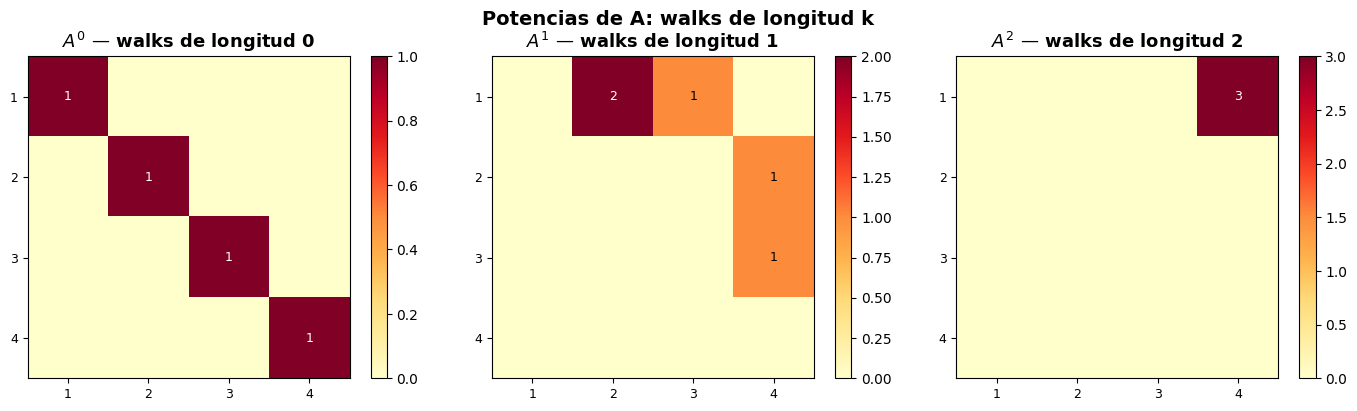

In [7]:
# Potencias de la matriz de adyacencia
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for k, ax in enumerate(axes):
    visualization.plot_impact_matrix(Q, k=k, ax=ax)
fig.suptitle("Potencias de A: walks de longitud k", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

**Verificación (Proposición 2.5):** $(A^k)_{ij}$ coincide con el número de walks dirigidos de longitud $k$ de $i$ a $j$.

Por ejemplo: $(A^2)_{1,4} = 3$ porque hay 3 walks de longitud 2 de 1 a 4:
- $\alpha_1 \cdot \beta$
- $\alpha_2 \cdot \beta$  
- $\gamma \cdot \delta$

---
## 3. Álgebra de Caminos kQ

**Definición 2.6:** El *álgebra de caminos* $kQ$ tiene como base el conjunto de todos los caminos dirigidos en $Q$, con multiplicación dada por concatenación (cuando es compatible) y cero en otro caso.

In [8]:
# Crear álgebra de caminos
kQ = PathAlgebra(Q)

# Caminos por grado
for k in range(Q.diameter() + 1):
    paths_k = kQ.enumerate_paths(k)
    print(f"\nGrado {k}: {len(paths_k)} caminos")
    for p in paths_k:
        print(f"  {p}  (de {p.source} a {p.target})")


Grado 0: 4 caminos
  e_1  (de 1 a 1)
  e_2  (de 2 a 2)
  e_3  (de 3 a 3)
  e_4  (de 4 a 4)

Grado 1: 5 caminos
  α₁  (de 1 a 2)
  α₂  (de 1 a 2)
  γ  (de 1 a 3)
  β  (de 2 a 4)
  δ  (de 3 a 4)

Grado 2: 3 caminos
  α₁ · β  (de 1 a 4)
  α₂ · β  (de 1 a 4)
  γ · δ  (de 1 a 4)


In [9]:
# Verificar Proposición 2.5: dim(e_i · kQ_k · e_j) = (A^k)_{ij}
print("Verificación de Proposición 2.5:")
print(f"{'(i,j,k)':>12} {'dim(e_i·kQ_k·e_j)':>20} {'(A^k)_ij':>10} {'OK?':>5}")
print("-" * 50)

all_ok = True
for k in range(Q.diameter() + 1):
    Ak = Q.adjacency_power(k)
    for i_idx, i in enumerate(verts):
        for j_idx, j in enumerate(verts):
            dim_ij = kQ.dimension(i, j, k)
            ak_ij = int(Ak[i_idx, j_idx])
            ok = dim_ij == ak_ij
            all_ok = all_ok and ok
            if dim_ij > 0 or ak_ij > 0:
                print(f"({i},{j},{k}):  {dim_ij:>15}  {ak_ij:>12}  {'✓' if ok else '✗':>5}")

print(f"\nProposición 2.5 {'verificada ✓' if all_ok else 'FALLA ✗'}")

Verificación de Proposición 2.5:
     (i,j,k)    dim(e_i·kQ_k·e_j)   (A^k)_ij   OK?
--------------------------------------------------
(1,1,0):                1             1      ✓
(2,2,0):                1             1      ✓
(3,3,0):                1             1      ✓
(4,4,0):                1             1      ✓
(1,2,1):                2             2      ✓
(1,3,1):                1             1      ✓
(2,4,1):                1             1      ✓
(3,4,1):                1             1      ✓
(1,4,2):                3             3      ✓

Proposición 2.5 verificada ✓


In [10]:
# Operaciones en el álgebra de caminos
# Construir caminos individuales
alpha1 = Path(Q, arrows=["α₁"])  # 1 → 2
alpha2 = Path(Q, arrows=["α₂"])  # 1 → 2
beta = Path(Q, arrows=["β"])     # 2 → 4
gamma = Path(Q, arrows=["γ"])    # 1 → 3
delta = Path(Q, arrows=["δ"])    # 3 → 4

# Concatenación
p1 = alpha1.concatenate(beta)  # α₁·β: 1→2→4
p2 = alpha2.concatenate(beta)  # α₂·β: 1→2→4
p3 = gamma.concatenate(delta)  # γ·δ: 1→3→4

print("Caminos de longitud 2 de 1 a 4:")
print(f"  {p1}")
print(f"  {p2}")
print(f"  {p3}")

# Combinación lineal
elem = PathAlgebraElement({p1: 1, p2: -1})
print(f"\nRelación: {elem}")
print("(Esto genera el ideal que fuerza α₁·β = α₂·β)")

Caminos de longitud 2 de 1 a 4:
  α₁ · β
  α₂ · β
  γ · δ

Relación: α₁ · β + -α₂ · β
(Esto genera el ideal que fuerza α₁·β = α₂·β)


---
## 4. Ideales y Cociente kQ/I

**Definición 2.8:** Un ideal $I$ de $kQ$ es *admisible* si $R^m \subseteq I \subseteq R^2$ donde $R = \bigoplus_{n \geq 1} kQ_n$.

El cociente $kQ/I$ reduce las dimensiones efectivas, modelando restricciones del sistema.

**Ejemplo:** Si $I = \langle \alpha_1\beta - \alpha_2\beta \rangle$, entonces los walks $\alpha_1\beta$ y $\alpha_2\beta$ se identifican en el cociente, reduciendo $\dim(e_1 \cdot (kQ/I)_2 \cdot e_4)$ de 3 a 2.

In [11]:
# Crear ideal I = <α₁β - α₂β>
relation = PathAlgebraElement({p1: 1, p2: -1})  # α₁β - α₂β
I = Ideal(kQ, [relation])

print(f"Ideal I generado por: {relation}")
print(f"¿Es admisible? {I.is_admissible()}")

# Crear cociente
kQI = QuotientAlgebra(kQ, I)

# Comparar dimensiones
print(f"\n{'Par (i,j)':>12} {'k':>4} {'dim kQ':>10} {'dim kQ/I':>10}")
print("-" * 40)
for k in range(Q.diameter() + 1):
    for i in verts:
        for j in verts:
            d_free = kQ.dimension(i, j, k)
            d_quot = kQI.dimension(i, j, k)
            if d_free > 0:
                marker = " ← reducido" if d_quot < d_free else ""
                print(f"({i},{j}):  {k:>6}  {d_free:>8}  {d_quot:>8}{marker}")

Ideal I generado por: α₁ · β + -α₂ · β
¿Es admisible? True

   Par (i,j)    k     dim kQ   dim kQ/I
----------------------------------------
(1,1):       0         1         1
(2,2):       0         1         1
(3,3):       0         1         1
(4,4):       0         1         1
(1,2):       1         2         2
(1,3):       1         1         1
(2,4):       1         1         1
(3,4):       1         1         1
(1,4):       2         3         2 ← reducido


**Resultado:** La dimensión $\dim(e_1 \cdot (kQ/I)_2 \cdot e_4)$ pasa de 3 a 2, porque la relación $\alpha_1\beta \sim \alpha_2\beta$ identifica dos de los tres walks.

Esto tiene consecuencia en la **tasa de impacto enriquecida**: menos walks efectivos implican una influencia reducida.

---
## 5. Sistema Fundamental de Vecindades (SFV)

**Definición 2.3:** Para una célula $c$, el SFV es la familia anidada:
$$\{c\} = A_0(c) \subseteq A_1(c) \subseteq \cdots \subseteq A_{g_{\max}}(c)$$

Las capas $N_g(c) = A_g(c) \setminus A_{g-1}(c)$ son los vértices a distancia exactamente $g$.

In [12]:
# SFV para cada vértice (dirección 'in': predecesores)
for cell in verts:
    fns = FundamentalNeighborhoodSystem(Q, cell, direction="in")
    print(f"\nSFV de célula {cell} (dirección: in):")
    for g in range(fns.g_max + 1):
        layer = fns.layer(g)
        ball = fns.A(g)
        print(f"  g={g}: N_{g}({cell}) = {layer},  A_{g}({cell}) = {ball},  Δ_{g} = {fns.Delta(g)}")
    print(f"  ¿Trampa topológica? {fns.is_topologically_trapped()}")


SFV de célula 1 (dirección: in):
  g=0: N_0(1) = {1},  A_0(1) = {1},  Δ_0 = 1
  g=1: N_1(1) = set(),  A_1(1) = {1},  Δ_1 = 0
  g=2: N_2(1) = set(),  A_2(1) = {1},  Δ_2 = 0
  ¿Trampa topológica? True

SFV de célula 2 (dirección: in):
  g=0: N_0(2) = {2},  A_0(2) = {2},  Δ_0 = 1
  g=1: N_1(2) = {1},  A_1(2) = {1, 2},  Δ_1 = 1
  g=2: N_2(2) = set(),  A_2(2) = {1, 2},  Δ_2 = 0
  ¿Trampa topológica? False

SFV de célula 3 (dirección: in):
  g=0: N_0(3) = {3},  A_0(3) = {3},  Δ_0 = 1
  g=1: N_1(3) = {1},  A_1(3) = {1, 3},  Δ_1 = 1
  g=2: N_2(3) = set(),  A_2(3) = {1, 3},  Δ_2 = 0
  ¿Trampa topológica? False

SFV de célula 4 (dirección: in):
  g=0: N_0(4) = {4},  A_0(4) = {4},  Δ_0 = 1
  g=1: N_1(4) = {2, 3},  A_1(4) = {2, 3, 4},  Δ_1 = 2
  g=2: N_2(4) = {1},  A_2(4) = {1, 2, 3, 4},  Δ_2 = 1
  ¿Trampa topológica? False


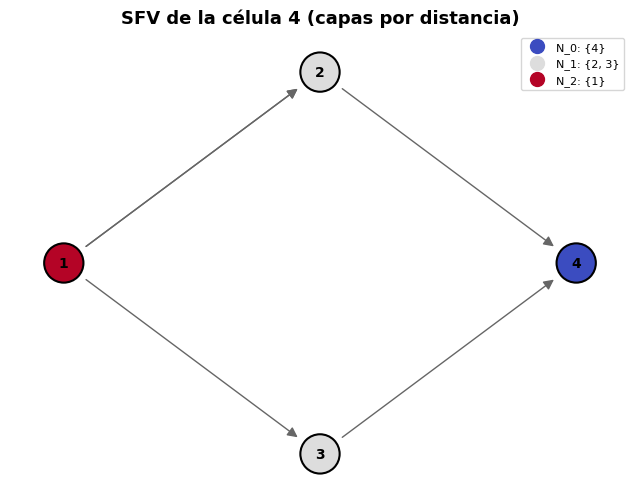

In [13]:
# Visualizar SFV del vértice 4
fns_4 = FundamentalNeighborhoodSystem(Q, 4, direction="in")
fig, ax = visualization.plot_sfv_layers(
    Q, 4, fns_4, pos=pos,
    title="SFV de la célula 4 (capas por distancia)",
)
plt.show()

**Observación:** El vértice 1 tiene in-degree 0, por lo que su SFV de entrada solo contiene a sí mismo: $N_0(1) = \{1\}$ y $N_g(1) = \emptyset$ para $g \geq 1$. Es una **trampa topológica** — una vez desactivado, no puede ser reactivado.

---
## 6. Tasas de Impacto

**Definición 2.9:** La tasa de impacto simple:
$$i^t(c) = \frac{\beta}{\alpha} \sum_{g=1}^{g_{\max}} \frac{\sigma_{g,K}^t(c)}{\Delta_g(c)} \cdot P(g)$$

donde $\sigma_{g,K}^t(c)$ cuenta vecinos en estado $K$ a distancia $g$, y $P(g)$ es la función de peso.

In [14]:
# Configuración del Ejemplo 2.7: {1:I, 2:S, 3:S, 4:S}
config = datasets.example_4node_initial_config()
print(f"Configuración π⁰: {config}")

# Parámetros del ejemplo
beta = 1.5
alpha = 1.0
P = lambda g: 1 / (2 ** (g - 1)) if g >= 1 else 1.0  # P(1)=1, P(2)=0.5

# Calcular tasas para cada vértice S
print(f"\nβ={beta}, α={alpha}, P(g) = 1/2^(g-1)")
print(f"\n{'Célula':>8} {'Estado':>8} {'Tasa i⁰(c)':>12} {'p_eff':>8}")
print("-" * 40)

for v in verts:
    rate = impact_rate_simple(Q, v, config, 'I', beta, alpha, P)
    p_eff = min(max(rate, 0), 1)
    print(f"{v:>8} {config[v]:>8} {rate:>12.4f} {p_eff:>8.4f}")

Configuración π⁰: {1: 'I', 2: 'S', 3: 'S', 4: 'S'}

β=1.5, α=1.0, P(g) = 1/2^(g-1)

  Célula   Estado   Tasa i⁰(c)    p_eff
----------------------------------------
       1        I       0.0000   0.0000
       2        S       1.5000   1.0000
       3        S       1.5000   1.0000
       4        S       0.7500   0.7500


**Verificación (Ejemplo 2.7):**
- $i^0(2) = \frac{1.5}{1} \cdot \frac{1}{1} \cdot 1 = 1.5$ → $p_{\text{eff}} = 1.0$ (truncado)
- $i^0(3) = \frac{1.5}{1} \cdot \frac{1}{1} \cdot 1 = 1.5$ → $p_{\text{eff}} = 1.0$
- $i^0(4) = \frac{1.5}{1} \cdot (\frac{0}{2} \cdot 1 + \frac{1}{1} \cdot 0.5) = 0.75$ → $p_{\text{eff}} = 0.75$

*(Los valores exactos dependen de la elección de P(g) y β/α.)*

---
## 7. Simulación SIS en Quiver de 4 Nodos (Ejemplo 3.1)

Ejecutamos el autómata AIQ con regla SIS sobre el quiver de 4 nodos.

In [15]:
# Crear AIQ con regla SIS
aiq = AIQ(
    quiver=Q,
    states=['S', 'I'],
    evolution_rule='SIS',
    beta=1.5,
    alpha=1.0,
    P=P,
    impact_mode='simple',
    recovery_prob=0.3,
)

# Configuración inicial
aiq.set_initial_config(config)
print(f"AIQ: {aiq}")
print(f"Configuración inicial: {aiq.config}")
print(f"Trampas topológicas: {aiq.topologically_trapped_vertices()}")

AIQ: AIQ(rule=SIS, |Q_0|=4, Σ=['S', 'I'], mode=simple, t=0)
Configuración inicial: {1: 'I', 2: 'S', 3: 'S', 4: 'S'}
Trampas topológicas: [1]


In [16]:
# Ejecutar 6 pasos con semilla fija
orbit = aiq.run(6, seed=42)

# Tabla de órbita
print("Órbita del AIQ:")
print(aiq.orbit_table())
print()
print("Conteo por estados:")
print(aiq.orbit_counts_table())

Órbita del AIQ:
   1  2  3  4
t            
0  I  S  S  S
1  S  I  I  S
2  S  I  I  I
3  S  I  S  I
4  S  S  S  I
5  S  S  S  I
6  S  S  S  S

Conteo por estados:
   S  I
t      
0  3  1
1  2  2
2  1  3
3  2  2
4  3  1
5  3  1
6  4  0


In [17]:
# Tabla estilizada (colores por estado)
visualization.orbit_table_styled(aiq)

,1,2,3,4
t,,,,
0,I,S,S,S
1,S,I,I,S
2,S,I,I,I
3,S,I,S,I
4,S,S,S,I
5,S,S,S,I
6,S,S,S,S


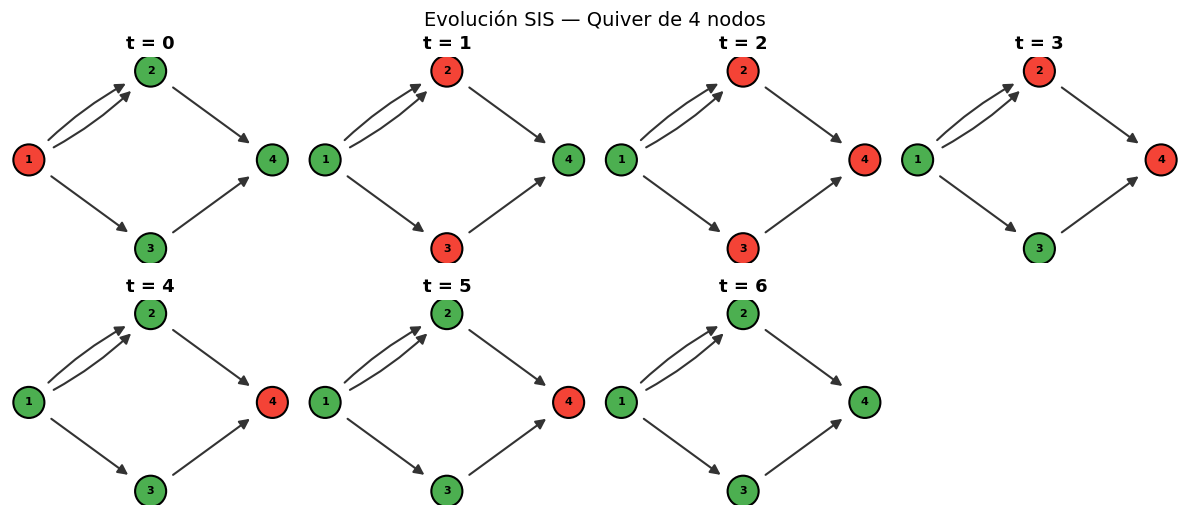

In [18]:
# Evolución visual del quiver
fig = visualization.draw_quiver_evolution(
    aiq, pos=pos, ncols=4,
    figsize_per_subplot=(3, 2.5),
)
fig.suptitle("Evolución SIS — Quiver de 4 nodos", fontsize=14, y=1.02)
plt.show()

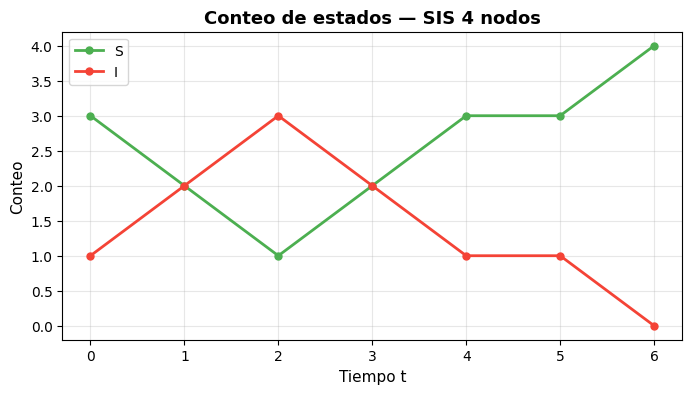

In [19]:
# Curvas de conteo
fig, ax = visualization.plot_evolution_counts(
    aiq, title="Conteo de estados — SIS 4 nodos"
)
plt.show()

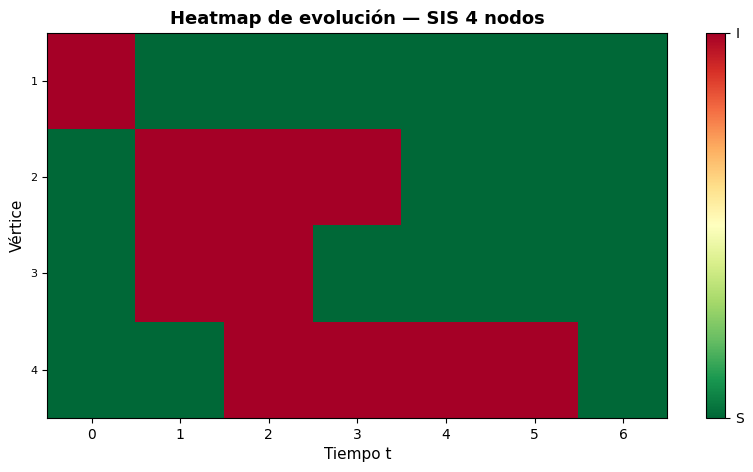

In [20]:
# Heatmap de evolución
fig, ax = visualization.plot_evolution_heatmap(
    aiq, title="Heatmap de evolución — SIS 4 nodos"
)
plt.show()

**Observación sobre trampas topológicas:** El vértice 1 es una fuente. En el modelo SIS, cuando 1 pasa de I a S por recuperación, no puede volver a I porque no tiene vecinos de entrada. Esto es la *trampa topológica* mencionada en el Ejemplo 3.1.

---
## 8. Quiver de Citación de 5 Artículos (Ejemplo 4.1)

Modelamos la dinámica de citación con 5 artículos. Las flechas representan citas: $P_i \to P_j$ significa que $P_i$ cita a $P_j$.

Los estados son:
- **R** (Relevante): artículo citado activamente
- **S** (Susceptible): artículo aún no activado
- **O** (Obsoleto): artículo que ya no es citado (en modelo SIR)

Quiver(|Q_0|=5, |Q_1|=6, vertices=['P1', 'P2', 'P3', 'P4', 'P5'])
  Flechas: a1:P1→P2, a2:P1→P3, a3:P2→P4, a4:P3→P4, a5:P3→P5, a6:P4→P5
  Fuentes (trampas topológicas): ['P1']
  Sumideros: ['P5']
  DAG: True
  Diámetro: 2


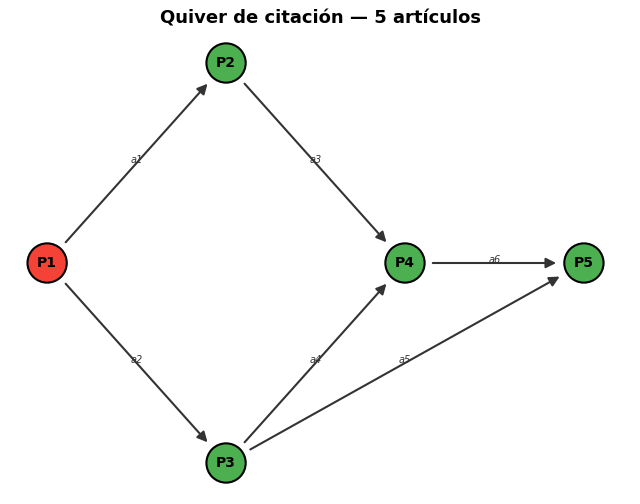

In [21]:
# Quiver de citación (Ejemplo 4.1)
Q_cit = datasets.example_5node_citation_quiver()
print(Q_cit.summary())

# Visualizar
pos_cit = {
    "P1": (0, 1), "P2": (1, 1.5), "P3": (1, 0.5),
    "P4": (2, 1), "P5": (3, 1),
}
config_cit = datasets.example_5node_citation_config()
state_colors_cit = {'R': '#F44336', 'S': '#4CAF50', 'O': '#9E9E9E'}

fig, ax = visualization.draw_quiver(
    Q_cit, config=config_cit, state_colors=state_colors_cit,
    pos=pos_cit, show_arrow_labels=True,
    title="Quiver de citación — 5 artículos",
)
plt.show()

In [22]:
# Vectores de impacto en el quiver de citación
print("Vectores de impacto seleccionados:")
for src, tgt in [("P1", "P5"), ("P1", "P4"), ("P2", "P5"), ("P1", "P2")]:
    v = impact_vector(Q_cit, src, tgt)
    d = impact_degree(Q_cit, src, tgt)
    print(f"  vec_g({src},{tgt}) = {v},  g({src},{tgt}) = {d}")

Vectores de impacto seleccionados:
  vec_g(P1,P5) = [0. 0. 1.],  g(P1,P5) = 2
  vec_g(P1,P4) = [0. 0. 2.],  g(P1,P4) = 2
  vec_g(P2,P5) = [0. 0. 1.],  g(P2,P5) = 2
  vec_g(P1,P2) = [0. 1. 0.],  g(P1,P2) = 1


In [23]:
# Simulación SIR: propagación de relevancia y obsolescencia
aiq_cit = AIQ(
    quiver=Q_cit,
    states=['S', 'R', 'O'],  # Susceptible, Relevante, Obsoleto
    evolution_rule='SIR',
    beta=1.0,
    alpha=1.0,
    P=lambda g: 1 / g if g >= 1 else 1.0,
    impact_mode='simple',
    recovery_prob=0.4,  # Probabilidad de obsolescencia
)

# P1 empieza como Relevante
aiq_cit.set_initial_config({
    'P1': 'R', 'P2': 'S', 'P3': 'S', 'P4': 'S', 'P5': 'S'
})

# Ejecutar
aiq_cit.run(8, seed=123)

# Tabla estilizada
print("Órbita del quiver de citación (SIR):")
visualization.orbit_table_styled(aiq_cit, state_colors=state_colors_cit)

Órbita del quiver de citación (SIR):


,P1,P2,P3,P4,P5
t,,,,,
0,R,S,S,S,S
1,O,R,R,S,R
2,O,R,R,R,O
3,O,O,O,R,O
4,O,O,O,R,O
5,O,O,O,R,O
6,O,O,O,O,O
7,O,O,O,O,O
8,O,O,O,O,O


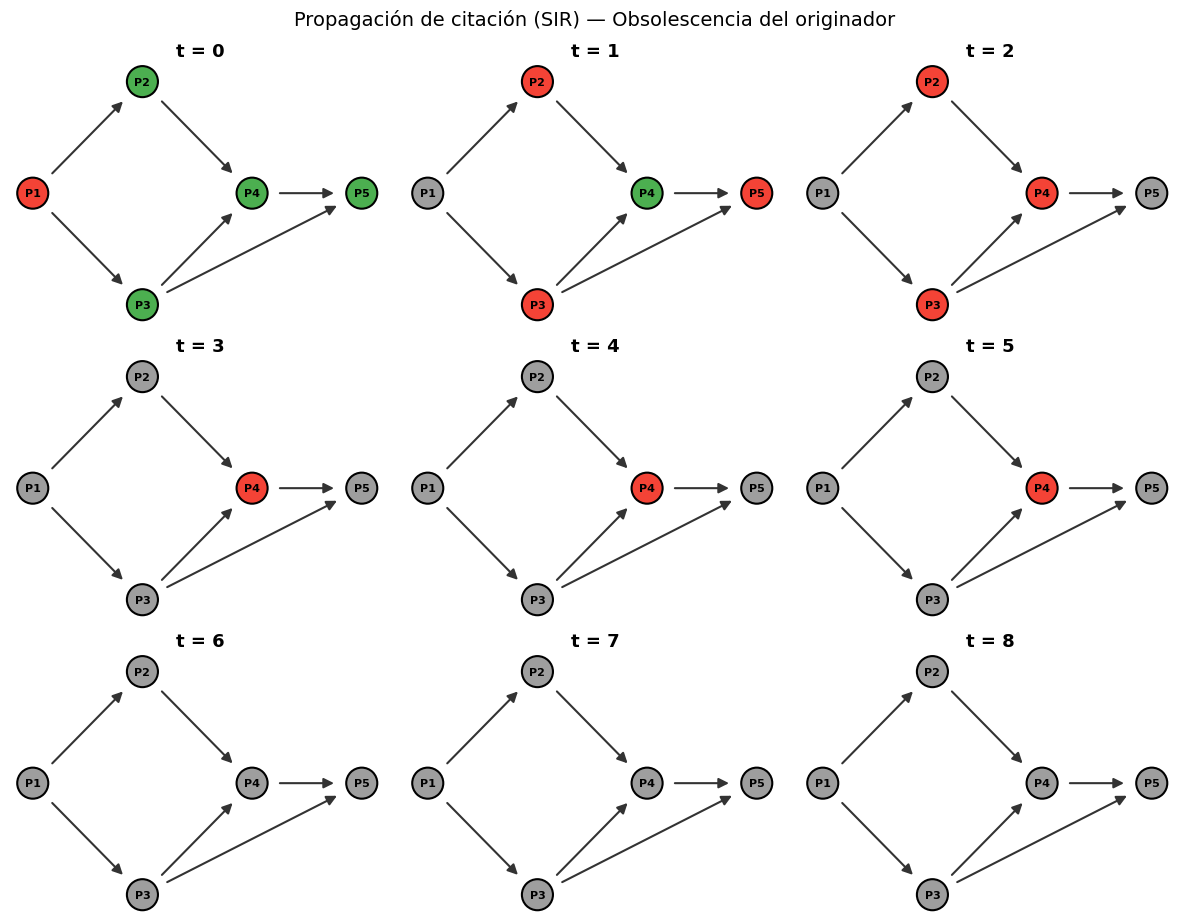

In [24]:
# Evolución visual
fig = visualization.draw_quiver_evolution(
    aiq_cit, pos=pos_cit, ncols=3,
    state_colors=state_colors_cit,
    figsize_per_subplot=(4, 3),
)
fig.suptitle("Propagación de citación (SIR) — Obsolescencia del originador",
             fontsize=14, y=1.02)
plt.show()

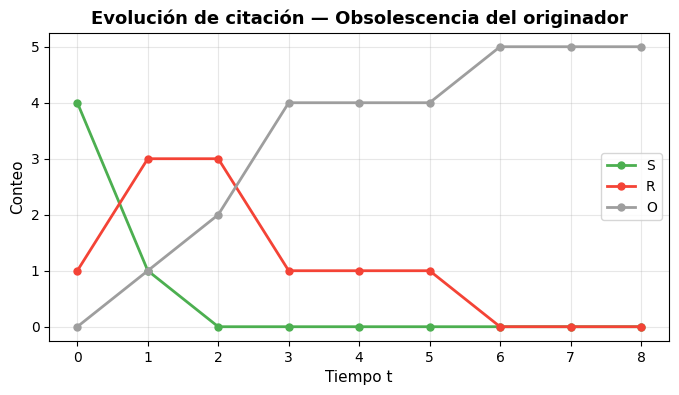

In [25]:
# Curvas de evolución
fig, ax = visualization.plot_evolution_counts(
    aiq_cit, state_colors=state_colors_cit,
    title="Evolución de citación — Obsolescencia del originador",
)
plt.show()

**Interpretación:** P1 (artículo originador) eventualmente se vuelve obsoleto (O), mientras la relevancia se propaga a artículos más recientes. Este es el fenómeno de *obsolescencia del conocimiento* que el AIQ captura naturalmente.

---
## 9. Tasa Enriquecida vs. Simple vs. con Ideal

Comparamos tres modos de tasa de impacto:
1. **Simple** (Def. 2.9): usa solo la topología (distancias)
2. **Enriquecida** (Def. 2.10): pondera por $(A^g)_{jc}$ — número de walks
3. **Enriquecida con ideal**: pondera por dimensiones del cociente $kQ/I$

In [26]:
# Comparación en el quiver de 4 nodos
config0 = {1: 'I', 2: 'S', 3: 'S', 4: 'S'}
beta_c = 1.0
alpha_c = 1.0
P_c = lambda g: 1 / g if g >= 1 else 1.0

print(f"Comparación de tasas de impacto (β={beta_c}, α={alpha_c}, P(g)=1/g):")
print(f"Configuración: {config0}")
print(f"\n{'Célula':>8} {'Simple':>10} {'Enriquecida':>12} {'Con ideal':>12}")
print("-" * 45)

for v in [2, 3, 4]:
    r_simple = impact_rate_simple(Q, v, config0, 'I', beta_c, alpha_c, P_c)
    r_enriched = impact_rate_enriched(Q, v, config0, 'I', beta_c, alpha_c, P_c)
    r_with_ideal = impact_rate_enriched(
        Q, v, config0, 'I', beta_c, alpha_c, P_c, quotient=kQI
    )
    print(f"{v:>8} {r_simple:>10.4f} {r_enriched:>12.4f} {r_with_ideal:>12.4f}")

Comparación de tasas de impacto (β=1.0, α=1.0, P(g)=1/g):
Configuración: {1: 'I', 2: 'S', 3: 'S', 4: 'S'}

  Célula     Simple  Enriquecida    Con ideal
---------------------------------------------
       2     1.0000       1.0000       1.0000
       3     1.0000       1.0000       1.0000
       4     0.5000       0.5000       0.5000


**Observación (Proposición 3.3):** La tasa con ideal es siempre $\leq$ la tasa enriquecida, porque el ideal reduce las dimensiones efectivas:
$$\dim(e_j \cdot (kQ/I)_g \cdot e_c) \leq \dim(e_j \cdot kQ_g \cdot e_c)$$

---
## 10. AIQ con Signo: Red de Regulación Génica

**Definición 2.11:** En un quiver con signo, cada flecha tiene peso $w(\alpha) \in \{+1, -1\}$:
- $+1$: activación / influencia positiva
- $-1$: inhibición / influencia negativa

La tasa de impacto con signo usa $W^g$ (matriz de adyacencia con signo elevada a la potencia $g$).

In [27]:
# Red de regulación génica (Ejemplo 4.5)
Q_gene = datasets.example_gene_regulatory_quiver()
print(Q_gene.summary())

print("\nPesos de flechas:")
for name, src, tgt in Q_gene.Q1:
    w = Q_gene.arrow_weight(name)
    tipo = "activación" if w > 0 else "inhibición"
    print(f"  {name}: {src} → {tgt} (w={w:+d}, {tipo})")

print(f"\nMatriz de adyacencia A (sin signo):")
print(Q_gene.adjacency_matrix())
print(f"\nMatriz de adyacencia W (con signo):")
print(Q_gene.signed_adjacency_matrix())

Quiver(|Q_0|=3, |Q_1|=3, vertices=['G1', 'G2', 'G3'])
  Flechas: act_12:G1→G2, inh_13:G1→G3, act_23:G2→G3
  Fuentes (trampas topológicas): ['G1']
  Sumideros: ['G3']
  DAG: True
  Diámetro: 1

Pesos de flechas:
  act_12: G1 → G2 (w=+1, activación)
  inh_13: G1 → G3 (w=-1, inhibición)
  act_23: G2 → G3 (w=+1, activación)

Matriz de adyacencia A (sin signo):
[[0. 1. 1.]
 [0. 0. 1.]
 [0. 0. 0.]]

Matriz de adyacencia W (con signo):
[[ 0.  1. -1.]
 [ 0.  0.  1.]
 [ 0.  0.  0.]]


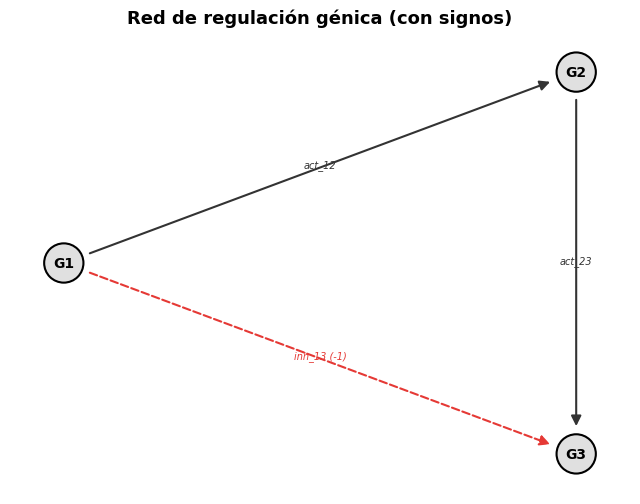

In [28]:
# Visualizar con signos
pos_gene = {"G1": (0, 1), "G2": (1, 1.5), "G3": (1, 0.5)}
fig, ax = visualization.draw_quiver(
    Q_gene, pos=pos_gene,
    show_arrow_labels=True, show_weights=True,
    title="Red de regulación génica (con signos)",
)
plt.show()

In [29]:
# Comparar tasa enriquecida vs. tasa con signo
config_gene = {"G1": "E", "G2": "S", "G3": "S"}  # G1 expresado
P_gene = lambda g: 1.0

print(f"Configuración: {config_gene}")
print(f"\n{'Gen':>5} {'Tasa enriched':>15} {'Tasa signed':>15} {'Diferencia':>12}")
print("-" * 50)

for v in ["G2", "G3"]:
    r_enrich = impact_rate_enriched(
        Q_gene, v, config_gene, 'E', 1.0, 1.0, P_gene
    )
    r_signed = impact_rate_signed(
        Q_gene, v, config_gene, 'E', 1.0, 1.0, P_gene
    )
    print(f"{v:>5} {r_enrich:>15.4f} {r_signed:>15.4f} {r_signed - r_enrich:>12.4f}")

print("\nLa inhibición G1→G3 reduce la tasa con signo para G3.")

Configuración: {'G1': 'E', 'G2': 'S', 'G3': 'S'}

  Gen   Tasa enriched     Tasa signed   Diferencia
--------------------------------------------------
   G2          1.0000          1.0000       0.0000
   G3          0.5000         -0.5000      -1.0000

La inhibición G1→G3 reduce la tasa con signo para G3.


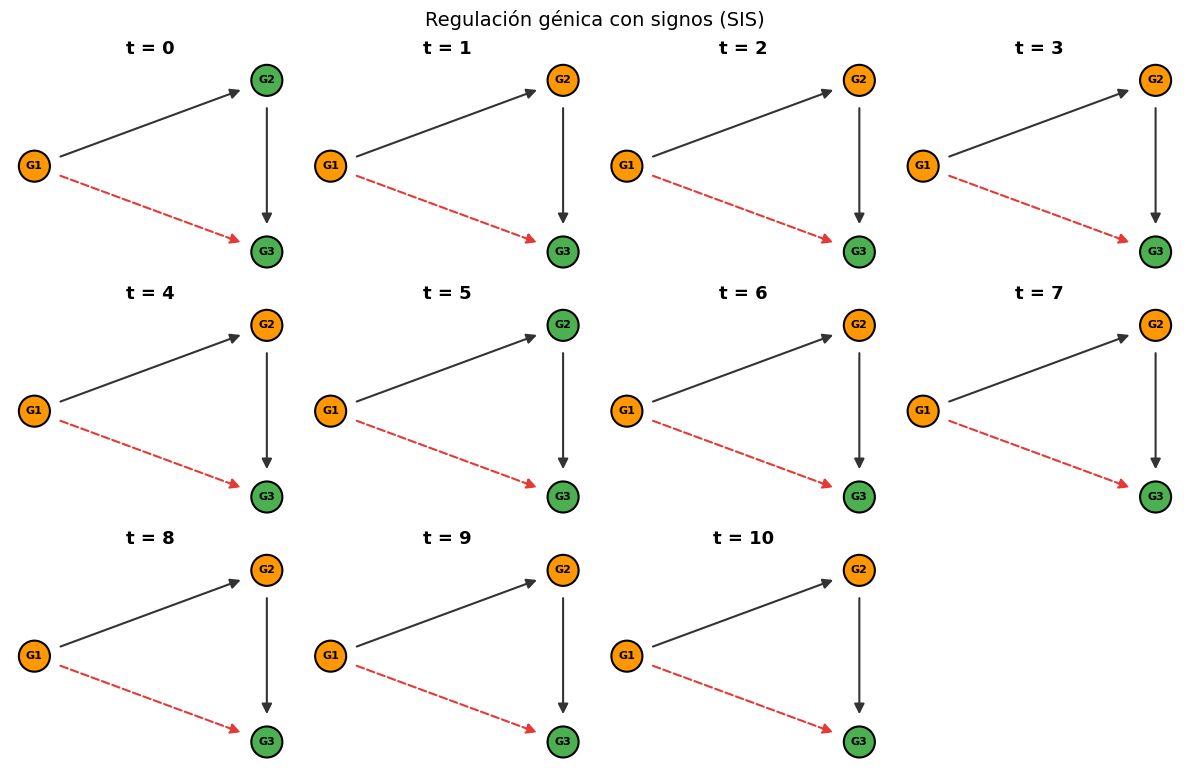

In [30]:
# Simulación con signo
aiq_gene = AIQ(
    quiver=Q_gene,
    states=['S', 'E'],  # Susceptible, Expresado
    evolution_rule='SIS',
    beta=1.0,
    alpha=1.0,
    P=P_gene,
    impact_mode='signed',
    recovery_prob=0.3,
    fixed_states={'G1': 'E'},  # G1 siempre expresado
)

aiq_gene.set_initial_config(config_gene)
aiq_gene.run(10, seed=42)

state_colors_gene = {'S': '#4CAF50', 'E': '#FF9800'}
fig = visualization.draw_quiver_evolution(
    aiq_gene, pos=pos_gene, ncols=4,
    state_colors=state_colors_gene,
    figsize_per_subplot=(3, 2.5),
)
fig.suptitle("Regulación génica con signos (SIS)", fontsize=14, y=1.02)
plt.show()

---
## 11. Dataset Cora

**Cora** es un dataset clásico de grafos de citación:
- 2,708 artículos científicos
- 5,429 aristas de citación
- 7 categorías temáticas

Lo cargamos como un subconjunto conexo de ~200 nodos para demos interactivas.

In [31]:
# Cargar subconjunto de Cora
Q_cora, meta_cora = datasets.load_cora_subset(n=200, seed=42)

print(f"Subconjunto de Cora:")
print(f"  Nodos: {Q_cora.n_vertices}")
print(f"  Aristas: {Q_cora.n_arrows}")
print(f"  Diámetro: {Q_cora.diameter()}")

# Estadísticas
sources = [v for v in Q_cora.Q0 if Q_cora.is_source(v)]
sinks = [v for v in Q_cora.Q0 if Q_cora.is_sink(v)]
print(f"  Fuentes (trampas topológicas): {len(sources)}")
print(f"  Sumideros: {len(sinks)}")
print(f"  DAG: {Q_cora.is_acyclic()}")

# Distribución de categorías
labels = [meta_cora[v]['label'] for v in Q_cora.Q0 if v in meta_cora]
label_counts = pd.Series(labels).value_counts()
print(f"\nCategorías:")
print(label_counts)

Descargando Cora desde https://linqs-data.soe.ucsc.edu/public/lbc/cora.tgz...
Extrayendo...
Cora descargado en /home/isaac-zainea/Dropbox/Documentos/Doctorado Matemáticas/quivers_analysis/data/cora
Subconjunto de Cora:
  Nodos: 200
  Aristas: 372
  Diámetro: 4
  Fuentes (trampas topológicas): 132
  Sumideros: 4
  DAG: False

Categorías:
Genetic_Algorithms        159
Neural_Networks            30
Reinforcement_Learning      6
Case_Based                  2
Theory                      2
Probabilistic_Methods       1
Name: count, dtype: int64


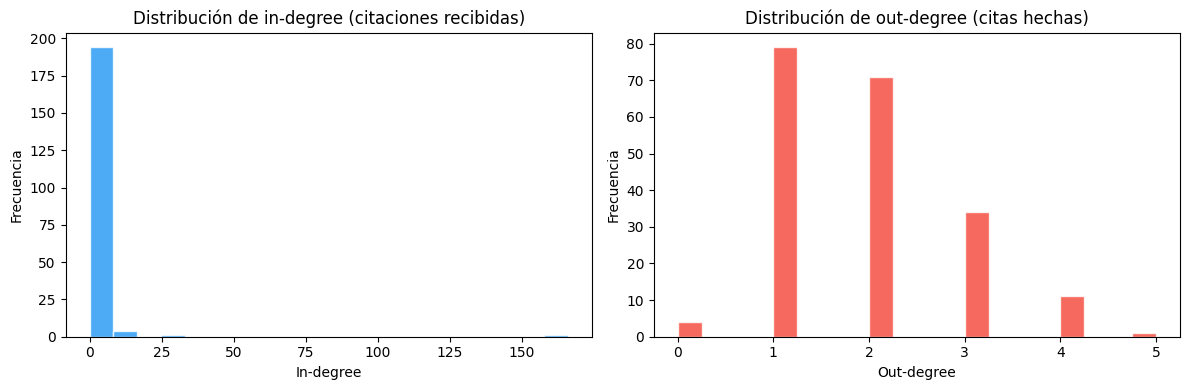

In [32]:
# Distribución de grado
in_degrees = [Q_cora.in_degree(v) for v in Q_cora.Q0]
out_degrees = [Q_cora.out_degree(v) for v in Q_cora.Q0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(in_degrees, bins=20, color='#2196F3', edgecolor='white', alpha=0.8)
ax1.set_xlabel('In-degree')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribución de in-degree (citaciones recibidas)')

ax2.hist(out_degrees, bins=20, color='#F44336', edgecolor='white', alpha=0.8)
ax2.set_xlabel('Out-degree')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de out-degree (citas hechas)')

fig.tight_layout()
plt.show()

---
## 12. Simulación AIQ en Cora

Simulamos la propagación de relevancia desde un artículo "seminal" (alto out-degree) usando el modelo SIS.

Artículo seminal: 1103960
  Out-degree: 5
  In-degree: 0
  Categoría: Genetic_Algorithms


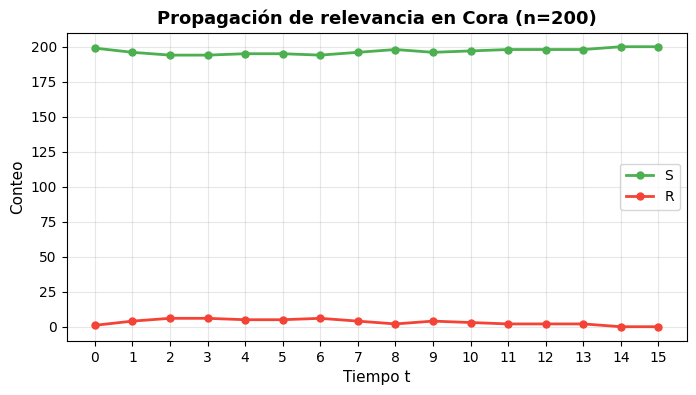

In [33]:
# Elegir artículo seminal: máximo out-degree
seminal = max(Q_cora.Q0, key=lambda v: Q_cora.out_degree(v))
print(f"Artículo seminal: {seminal}")
print(f"  Out-degree: {Q_cora.out_degree(seminal)}")
print(f"  In-degree: {Q_cora.in_degree(seminal)}")
if seminal in meta_cora:
    print(f"  Categoría: {meta_cora[seminal]['label']}")

# Configuración inicial: solo el seminal es R
config_cora = {v: 'S' for v in Q_cora.Q0}
config_cora[seminal] = 'R'

# AIQ SIS
aiq_cora = AIQ(
    quiver=Q_cora,
    states=['S', 'R'],
    evolution_rule='SIS',
    beta=1.2,
    alpha=1.0,
    P=lambda g: 1.0 / g if g >= 1 else 1.0,
    g_max=3,  # Limitar por eficiencia
    impact_mode='simple',
    recovery_prob=0.2,
)

aiq_cora.set_initial_config(config_cora)
aiq_cora.run(15, seed=42)

# Curvas de evolución
fig, ax = visualization.plot_evolution_counts(
    aiq_cora,
    state_colors={'S': '#4CAF50', 'R': '#F44336'},
    title=f"Propagación de relevancia en Cora (n={Q_cora.n_vertices})",
)
plt.show()

Nodos que alguna vez fueron Relevantes: 6 de 200


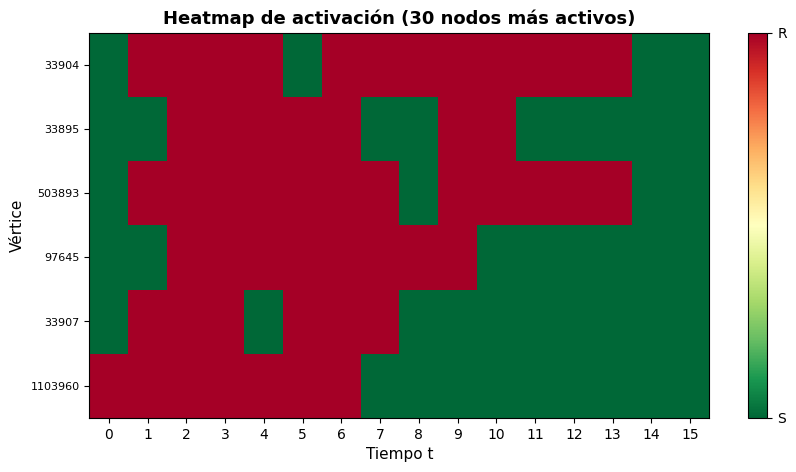

In [34]:
# Heatmap (subconjunto de 30 nodos más activos)
orbit = aiq_cora.orbit

# Encontrar nodos que alguna vez fueron R
ever_R = set()
for cfg in orbit:
    for v, s in cfg.items():
        if s == 'R':
            ever_R.add(v)

print(f"Nodos que alguna vez fueron Relevantes: {len(ever_R)} de {Q_cora.n_vertices}")

# Sub-quiver de nodos activos para visualización
active_subset = list(ever_R)[:30]
if active_subset:
    Q_active = Q_cora.subquiver(active_subset)
    # Crear AIQ temporal para heatmap
    aiq_active = AIQ(
        quiver=Q_active, states=['S', 'R'],
        evolution_rule='SIS', beta=1.2, alpha=1.0,
        P=lambda g: 1.0 / g if g >= 1 else 1.0,
    )
    # Reconstruir órbita restringida
    restricted_orbit = []
    for cfg in orbit:
        restricted_orbit.append({v: cfg.get(v, 'S') for v in active_subset})
    aiq_active._orbit = restricted_orbit
    aiq_active._config = restricted_orbit[-1]

    fig, ax = visualization.plot_evolution_heatmap(
        aiq_active,
        title="Heatmap de activación (30 nodos más activos)",
        state_encoding={'S': 0, 'R': 1},
    )
    plt.show()

---
## 13. Estadísticas Monte Carlo

Ejecutamos 100 realizaciones independientes para obtener la evolución promedio con bandas de incertidumbre.

In [35]:
# Monte Carlo: 100 realizaciones
stats = aiq_cora.run_statistics(
    initial_config=config_cora,
    n_steps=15,
    n_runs=100,
    seed=123,
)

print(stats.head(10))

   t state    mean       std  min  max
0  0     S  199.00  0.000000  199  199
1  0     R    1.00  0.000000    1    1
2  1     S  196.71  0.982802  194  199
3  1     R    3.29  0.982802    1    6
4  2     S  196.13  1.324047  193  199
5  2     R    3.87  1.324047    1    7
6  3     S  196.17  1.510331  193  200
7  3     R    3.83  1.510331    0    7
8  4     S  196.10  1.763519  192  200
9  4     R    3.90  1.763519    0    8


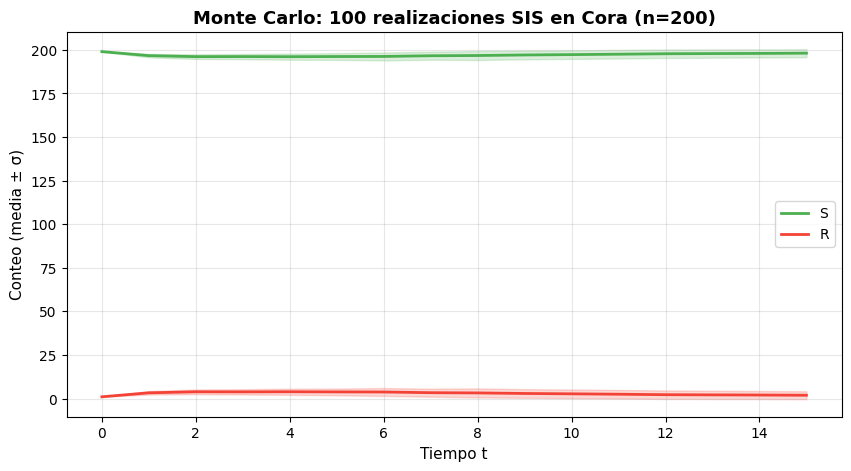

In [36]:
# Gráfica con bandas de incertidumbre
fig, ax = visualization.plot_statistics(
    stats,
    state_colors={'S': '#4CAF50', 'R': '#F44336'},
    title=f"Monte Carlo: 100 realizaciones SIS en Cora (n={Q_cora.n_vertices})",
)
plt.show()

**Interpretación:** Las bandas muestran la variabilidad inherente al proceso estocástico. La propagación de relevancia alcanza un equilibrio dinámico en el modelo SIS, donde la tasa de infección y recuperación se balancean.

---
## 14. Morfismos de Quivers y AIQs

**Definición 3.2:** Un morfismo de quivers $f: Q \to Q'$ consta de:
- $f_0: Q_0 \to Q'_0$ (mapa de vértices)
- $f_1: Q_1 \to Q'_1$ (mapa de flechas)

satisfaciendo $s' \circ f_1 = f_0 \circ s$ y $t' \circ f_1 = f_0 \circ t$.

In [37]:
# Isomorfismo por reetiquetado
relabel = {1: 'A', 2: 'B', 3: 'C', 4: 'D'}
iso = morphisms.relabeling_isomorphism(Q, relabel)

print(f"Morfismo de reetiquetado: {iso}")
print(f"  f_0: {iso.vertex_map}")
print(f"  f_1: {iso.arrow_map}")
print(f"  ¿Es isomorfismo? {iso.is_isomorphism()}")
print(f"  ¿Inyectivo en vértices? {iso.is_injective_on_vertices()}")
print(f"  ¿Sobreyectivo en vértices? {iso.is_surjective_on_vertices()}")

Morfismo de reetiquetado: QuiverMorphism(|Q_0|=4→4, iso=True)
  f_0: {1: 'A', 2: 'B', 3: 'C', 4: 'D'}
  f_1: {'α₁': 'α₁_r', 'α₂': 'α₂_r', 'γ': 'γ_r', 'β': 'β_r', 'δ': 'δ_r'}
  ¿Es isomorfismo? True
  ¿Inyectivo en vértices? True
  ¿Sobreyectivo en vértices? True


In [38]:
# Quiver reetiquetado
Q_relabeled = iso.target
print(Q_relabeled.summary())

# Verificar que la estructura se preserva
print(f"\nA original:")
print(Q.adjacency_matrix())
print(f"\nA reetiquetada:")
print(Q_relabeled.adjacency_matrix())
print("\n¿Matrices iguales?", np.allclose(
    Q.adjacency_matrix(), Q_relabeled.adjacency_matrix()
))

Quiver(|Q_0|=4, |Q_1|=5, vertices=['A', 'B', 'C', 'D'])
  Flechas: α₁_r:A→B, α₂_r:A→B, γ_r:A→C, β_r:B→D, δ_r:C→D
  Fuentes (trampas topológicas): ['A']
  Sumideros: ['D']
  DAG: True
  Diámetro: 2

A original:
[[0. 2. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 0.]]

A reetiquetada:
[[0. 2. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 0.]]

¿Matrices iguales? True


In [39]:
# Morfismo identidad y composición
id_Q = morphisms.identity_morphism(Q)
print(f"Identidad: {id_Q}")

# Composición: id ∘ iso = iso
composed = id_Q.compose(iso)
print(f"id ∘ reetiquetado: {composed}")
print(f"  f_0 compuesto: {composed.vertex_map}")

Identidad: QuiverMorphism(|Q_0|=4→4, iso=True)
id ∘ reetiquetado: QuiverMorphism(|Q_0|=4→4, iso=True)
  f_0 compuesto: {1: 'A', 2: 'B', 3: 'C', 4: 'D'}


In [40]:
# Inclusión de sub-quiver (Ejemplo 3.4)
sub_verts = [1, 2, 4]
incl = morphisms.subquiver_inclusion(Q, sub_verts)
Q_sub = incl.source

print(f"Sub-quiver Q|_{{{', '.join(map(str, sub_verts))}}}:")
print(Q_sub.summary())
print(f"\nInclusión: {incl}")

# Frontera de influencia
boundary = Q.influence_boundary(sub_verts, g_max=1)
print(f"\nFrontera de influencia ∂¹S = {boundary}")
print("(Vértices fuera de S con caminos de longitud ≤ 1 hacia S)")

Sub-quiver Q|_{1, 2, 4}:
Quiver(|Q_0|=3, |Q_1|=3, vertices=[1, 2, 4])
  Flechas: α₁:1→2, α₂:1→2, β:2→4
  Fuentes (trampas topológicas): [1]
  Sumideros: [4]
  DAG: True
  Diámetro: 2

Inclusión: QuiverMorphism(|Q_0|=3→4, iso=False)

Frontera de influencia ∂¹S = {3}
(Vértices fuera de S con caminos de longitud ≤ 1 hacia S)


Quiver opuesto Q^op (flechas invertidas):
Quiver(|Q_0|=4, |Q_1|=5, vertices=[1, 2, 3, 4])
  Flechas: α₁_op:2→1, α₂_op:2→1, γ_op:3→1, β_op:4→2, δ_op:4→3
  Fuentes (trampas topológicas): [4]
  Sumideros: [1]
  DAG: True
  Diámetro: 2


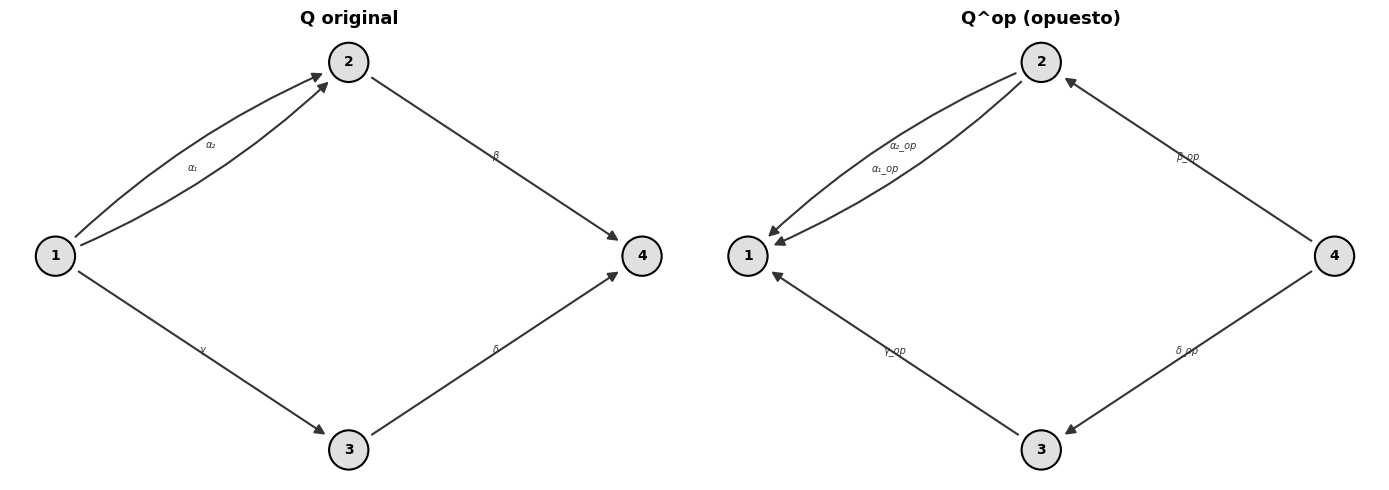

In [41]:
# Quiver opuesto (Proposición 3.2)
Q_op = Q.opposite()
print("Quiver opuesto Q^op (flechas invertidas):")
print(Q_op.summary())

# Visualizar lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
visualization.draw_quiver(Q, pos=pos, ax=ax1, title="Q original",
                          show_arrow_labels=True)
visualization.draw_quiver(Q_op, pos=pos, ax=ax2, title="Q^op (opuesto)",
                          show_arrow_labels=True)
plt.tight_layout()
plt.show()

In [42]:
# Quiver simétrico (Proposición 3.1)
Q_sym = Q.symmetrize()
print("Quiver simétrico Q_G:")
print(Q_sym.summary())
print("\n(Se añaden flechas inversas donde no existían)")

Quiver simétrico Q_G:
Quiver(|Q_0|=4, |Q_1|=9, vertices=[1, 2, 3, 4])
  Flechas: α₁:1→2, α₂:1→2, γ:1→3, β:2→4, δ:3→4, _sym_0:2→1, _sym_1:3→1, _sym_2:4→2, _sym_3:4→3
  DAG: False
  Diámetro: 2

(Se añaden flechas inversas donde no existían)


---
## Resumen

Este notebook ha demostrado los siguientes componentes del marco AIQ:

| Concepto | Referencia | Implementación |
|----------|-----------|----------------|
| Quiver $Q = (Q_0, Q_1, s, t)$ | Def. 2.4 | `Quiver` |
| Grado de impacto $g(c_i, c_j)$ | Def. 2.2 | `impact_degree()` |
| Vector de impacto $\vec{g}$ | Def. 2.5 | `impact_vector()` |
| Álgebra de caminos $kQ$ | Def. 2.6 | `PathAlgebra` |
| Cociente $kQ/I$ | Def. 2.8 | `QuotientAlgebra` |
| SFV $\{A_k(c)\}$ | Def. 2.3 | `FundamentalNeighborhoodSystem` |
| Tasa de impacto simple | Def. 2.9 | `impact_rate_simple()` |
| Tasa enriquecida | Def. 2.10 | `impact_rate_enriched()` |
| Tasa con signo | Def. 2.11 | `impact_rate_signed()` |
| AIQ $(Q, \Sigma, \{A_k\}, \varphi)$ | Def. 3.1 | `AIQ` |
| Morfismos de quivers | Def. 3.2 | `QuiverMorphism` |
| Morfismos de AIQs | Defs. 3.3–3.5 | `AIQMorphism` |

### Aplicaciones demostradas:
1. **Grafos de citación** (Ejemplo 4.1): propagación y obsolescencia del conocimiento
2. **Regulación génica** (Ejemplo 4.5): activación/inhibición con signos
3. **Dataset Cora**: simulación a escala real con estadísticas Monte Carlo